In [1]:
import pandas as pd
import numpy as np

In [2]:
delivery=pd.read_csv('deliveries.csv')
match=pd.read_csv('matches.csv')

In [3]:
delivery

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150455,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
150456,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,0,0,0,CJ Jordan,run out,NV Ojha
150457,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,B Kumar,0,...,0,1,0,0,0,1,1,NaN,NaN,NaN
150458,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,B Kumar,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN


In [4]:
runs=delivery.groupby('batsman')
print(runs)

In [5]:
runs['batsman_runs'].sum().sort_values(ascending=False).head(10)

batsman
SK Raina          4548
V Kohli           4423
RG Sharma         4207
G Gambhir         4132
DA Warner         4014
RV Uthappa        3778
CH Gayle          3651
S Dhawan          3561
MS Dhoni          3560
AB de Villiers    3486
Name: batsman_runs, dtype: int64

In [6]:
#batsman max fours

In [7]:
mask=delivery['batsman_runs']==3
new_delivery=delivery[mask]
new_delivery.shape[0]

509

In [8]:
new_delivery.groupby('batsman')['batsman_runs'].count().sort_values(ascending=False).head(5)

batsman
M Vijay      17
S Dhawan     16
G Gambhir    15
AM Rahane    14
DA Warner    13
Name: batsman_runs, dtype: int64

In [9]:
mask=delivery[delivery['batsman']=='V Kohli']

In [10]:
mask.groupby('bowling_team')['batsman_runs'].sum().sort_values(ascending=False).head(10)

bowling_team
Chennai Super Kings        706
Delhi Daredevils           661
Kings XI Punjab            483
Mumbai Indians             447
Sunrisers Hyderabad        439
Kolkata Knight Riders      391
Deccan Chargers            306
Gujarat Lions              283
Rajasthan Royals           258
Rising Pune Supergiants    188
Name: batsman_runs, dtype: int64

#function takes batsman name sends  team agst which max runs

In [11]:
def run_scored(batsman_name):
    mask=delivery[delivery['batsman']==batsman_name]
    return mask.groupby('bowling_team')['batsman_runs'].sum().sort_values(ascending=False).index[0]

In [12]:
# def run_scored(batsman_name):
#     mask = delivery[delivery['batsman'] == batsman_name]
#     return mask.groupby('bowling_team')['batsman_runs'].sum().idxmax()

In [13]:
run_scored('DA Warner')

'Kolkata Knight Riders'

In [14]:
#isin function => most destructive death over batsman in history of ipl
# by strike rate =( no. of balls/100) 100 ball me kitne runs
#min batsman 200 balls in over 16-20

In [15]:
death_over=delivery[delivery['over']>15] #over>16 wale entrires

In [16]:
#delivery.groupby('batsman')['batsman_runs'].count() # no. of balss keli h kisne kitni
#death_over.groupby('batsman')['batsman_runs'].count() # 16+ over wale me
death_over.groupby('batsman')['batsman_runs'].count()>200 

batsman
A Ashish Reddy    False
A Chandila        False
A Chopra          False
A Choudhary       False
A Flintoff        False
                  ...  
YS Chahal         False
YV Takawale       False
Yashpal Singh     False
Yuvraj Singh       True
Z Khan            False
Name: batsman_runs, Length: 416, dtype: bool

In [17]:
all_batsman=death_over.groupby('batsman')['batsman_runs'].count()
x=all_batsman>200 #boolean series in variable x
all_batsman[x] #for true only series  name and balls
all_batsman[x].index

Index(['A Mishra', 'AB de Villiers', 'AD Mathews', 'AM Rahane', 'AR Patel',
       'AT Rayudu', 'BJ Hodge', 'DA Miller', 'DA Warner', 'DJ Bravo',
       'DJ Hussey', 'DPMD Jayawardene', 'Harbhajan Singh', 'IK Pathan',
       'JA Morkel', 'JH Kallis', 'JP Duminy', 'JP Faulkner', 'KA Pollard',
       'KD Karthik', 'KM Jadhav', 'LRPL Taylor', 'MK Pandey', 'MK Tiwary',
       'MS Dhoni', 'NV Ojha', 'P Kumar', 'PP Chawla', 'R Vinay Kumar',
       'RA Jadeja', 'RG Sharma', 'RV Uthappa', 'S Badrinath', 'S Dhawan',
       'SK Raina', 'SPD Smith', 'SS Tiwary', 'STR Binny', 'V Kohli', 'WP Saha',
       'Y Venugopal Rao', 'YK Pathan', 'Yuvraj Singh'],
      dtype='object', name='batsman')

In [18]:
batsman_list=all_batsman[x].index.tolist()

In [19]:
#to cal strike rate we need 
#runs scored by all these 43 batsman 
#balls p;ayed by these 43 batsman 
delivery #but i just want these 43 batsman so 
final=delivery[delivery['batsman'].isin(batsman_list)]
final.groupby('batsman')['batsman_runs'].sum()
runs=final.groupby('batsman')['batsman_runs'].sum()
balls=final.groupby('batsman')['batsman_runs'].count()

In [20]:
sr=(runs/balls)*100

In [21]:
sr

batsman
A Mishra             89.005236
AB de Villiers      145.129059
AD Mathews          120.868114
AM Rahane           117.486549
AR Patel            122.672065
AT Rayudu           123.014257
BJ Hodge            121.422376
DA Miller           137.709251
DA Warner           138.318401
DJ Bravo            122.286822
DJ Hussey           120.072661
DPMD Jayawardene    118.791064
Harbhajan Singh     135.194585
IK Pathan           116.751269
JA Morkel           136.938202
JH Kallis           105.936272
JP Duminy           121.970624
JP Faulkner         129.802956
KA Pollard          140.621266
KD Karthik          123.008475
KM Jadhav           130.555556
LRPL Taylor         120.070838
MK Pandey           116.938453
MK Tiwary           114.127424
MS Dhoni            132.835821
NV Ojha             114.528024
P Kumar             105.263158
PP Chawla           110.278373
R Vinay Kumar       106.666667
RA Jadeja           118.792867
RG Sharma           128.497251
RV Uthappa          127.635135


In [22]:
match=pd.read_csv('matches.csv')
# merge
new=delivery.merge(match,left_on='match_id',right_on='id')

In [23]:
print(delivery.shape)
print(match.shape)

(150460, 21)
(636, 18)


In [24]:
#now new.groupby('batsman')['batsman_runs'].sum() gives batsman and runs
new.groupby(['season','batsman'])['batsman_runs'].sum() #gives multi index series but iwant top batsman every season
new.groupby(['season','batsman'])['batsman_runs'].sum().reset_index() #helps create df

,season,batsman,batsman_runs
0,2008,A Chopra,42
1,2008,A Kumble,13
2,2008,A Mishra,37
3,2008,A Mukund,0
4,2008,A Nehra,3
...,...,...,...
1526,2017,Washington Sundar,9
1527,2017,YK Pathan,143
1528,2017,YS Chahal,13
1529,2017,Yuvraj Singh,252


In [25]:
#still not close we wanted season - batsman 
new.groupby(['season','batsman'])['batsman_runs'].sum().sort_values(ascending=False).reset_index()

,season,batsman,batsman_runs
0,2016,V Kohli,973
1,2016,DA Warner,848
2,2013,MEK Hussey,733
3,2012,CH Gayle,733
4,2013,CH Gayle,720
...,...,...,...
1526,2017,MM Patel,0
1527,2012,AC Blizzard,0
1528,2011,AB Dinda,0
1529,2017,AD Nath,0


In [26]:
new.groupby(['season','batsman'])['batsman_runs'].sum().sort_values(ascending=False).reset_index().drop_duplicates(subset='season',keep='first').sort_values('season')

,season,batsman,batsman_runs
10,2008,SE Marsh,616
14,2009,ML Hayden,572
9,2010,SR Tendulkar,618
11,2011,CH Gayle,608
3,2012,CH Gayle,733
2,2013,MEK Hussey,733
6,2014,RV Uthappa,660
17,2015,DA Warner,562
0,2016,V Kohli,973
7,2017,DA Warner,641


In [27]:
#i wanted only season and batsman
new.groupby(['season','batsman'])['batsman_runs'].sum().sort_values(ascending=False).reset_index().drop_duplicates(subset='season',keep='first').sort_values('season')[['season','batsman']]

,season,batsman
10,2008,SE Marsh
14,2009,ML Hayden
9,2010,SR Tendulkar
11,2011,CH Gayle
3,2012,CH Gayle
2,2013,MEK Hussey
6,2014,RV Uthappa
17,2015,DA Warner
0,2016,V Kohli
7,2017,DA Warner


In [28]:
#pivot table
#col teams ,row= 1-20 , 

mask=delivery['batsman_runs']==6
six=delivery[mask]
six.shape

(6523, 21)

In [29]:
pt=six.pivot_table(index='over',columns='batting_team',values='batsman_runs',aggfunc='count')

In [30]:
import seaborn as sns

<Axes: xlabel='batting_team', ylabel='over'>

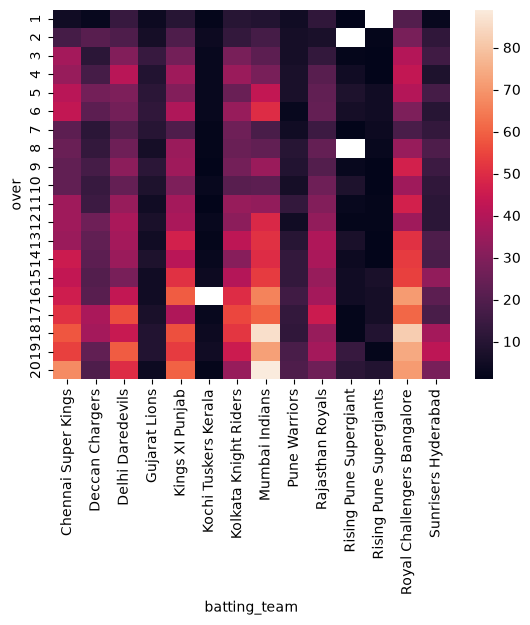

In [31]:
sns.heatmap(pt)

In [32]:
#corelation function =>num data pe
match.corr(numeric_only=True)


,id,season,dl_applied,win_by_runs,win_by_wickets,umpire3
id,1.000000,0.471087,0.024281,-0.010263,-0.015510,NaN
season,0.471087,1.000000,0.004170,-0.016815,-0.000708,NaN
dl_applied,0.024281,0.004170,1.000000,-0.010893,-0.011640,NaN
win_by_runs,-0.010263,-0.016815,-0.010893,1.000000,-0.565181,NaN
win_by_wickets,-0.015510,-0.000708,-0.011640,-0.565181,1.000000,NaN
umpire3,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

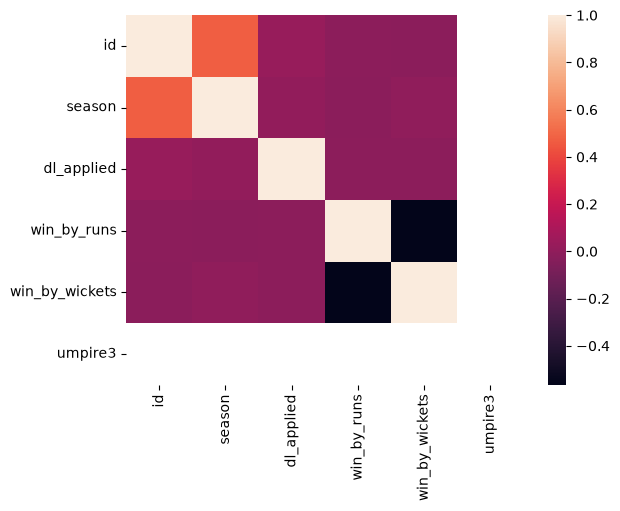

In [33]:
sns.heatmap(match.corr(numeric_only=True))

In [34]:
#weird name h toh rename cols

In [35]:
match


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [36]:
#city and date->place and dom

In [37]:
match.rename (columns = {'city':'place','date':'dom'})

,id,season,place,dom,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [38]:
#to permanent change
# inplce =true

In [39]:
match.set_index('id')


,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
id,,,,,,,,,,,,,,,,,
1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN


In [40]:
match['winner'].value_counts().reset_index()

,winner,count
0,Mumbai Indians,92
1,Chennai Super Kings,79
2,Kolkata Knight Riders,77
3,Royal Challengers Bangalore,73
4,Kings XI Punjab,70
5,Rajasthan Royals,63
6,Delhi Daredevils,62
7,Sunrisers Hyderabad,42
8,Deccan Chargers,29
9,Gujarat Lions,13


In [41]:
#handling missing values
#drop or fill

In [42]:
match.shape

(636, 18)

In [43]:
match.dropna(how='all').shape

(636, 18)

In [44]:
match.dropna(axis=1,how='all').shape

(636, 17)

In [45]:
#fillna

In [46]:
match.fillna(0)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,0.0
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,0.0
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,0.0
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,0.0
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,0.0
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,0.0
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,0.0
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,0.0


In [47]:
#isme string also 0 so ill pput in a col
match['dl_applied'].fillna("Not Specified",inplace=True)

C:\Users\suhav\AppData\Local\Temp\ipykernel_15452\594722384.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  match['dl_applied'].fillna("Not Specified",inplace=True)


In [59]:
delivery.head(5)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [52]:
match.sample(5)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
158,159,2009,Durban,2009-05-14,Chennai Super Kings,Royal Challengers Bangalore,Chennai Super Kings,bat,normal,0,Royal Challengers Bangalore,0,2,LRPL Taylor,Kingsmead,BR Doctrove,DJ Harper,NaN
146,147,2009,Centurion,2009-05-06,Deccan Chargers,Mumbai Indians,Deccan Chargers,bat,normal,0,Deccan Chargers,19,0,RG Sharma,SuperSport Park,MR Benson,HDPK Dharmasena,NaN
601,602,2016,Delhi,2016-04-30,Delhi Daredevils,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Delhi Daredevils,27,0,CR Brathwaite,Feroz Shah Kotla,KN Ananthapadmanabhan,M Erasmus,NaN
78,79,2008,Chennai,2008-05-02,Chennai Super Kings,Delhi Daredevils,Chennai Super Kings,bat,normal,0,Delhi Daredevils,0,8,V Sehwag,"MA Chidambaram Stadium, Chepauk",BF Bowden,K Hariharan,NaN
389,390,2013,Mumbai,2013-04-09,Mumbai Indians,Delhi Daredevils,Mumbai Indians,bat,normal,0,Mumbai Indians,44,0,KD Karthik,Wankhede Stadium,M Erasmus,VA Kulkarni,NaN


In [53]:
import seaborn as sns

<Axes: xlabel='winner', ylabel='count'>

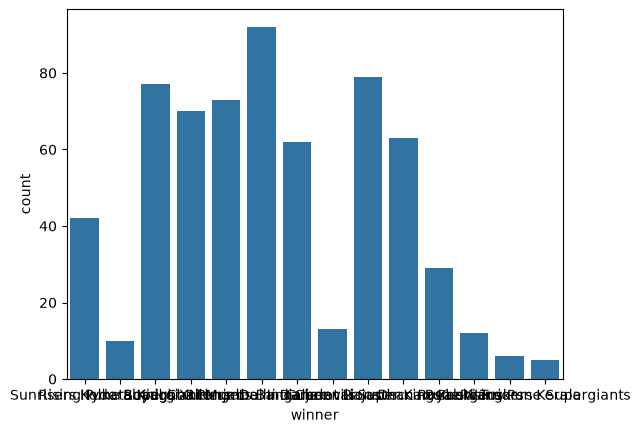

In [54]:
sns.countplot(x='winner', data=match)


<Axes: ylabel='count'>

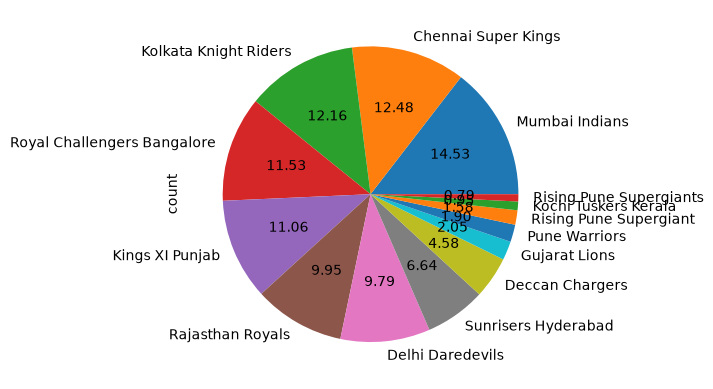

In [58]:
import matplotlib.pyplot as plt
match['winner'].value_counts().plot(kind='pie',autopct='%.2f')

In [62]:
sns.distplot(match['win_by_runs']bin=5)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3163257072.py, line 1)

(array([531.,  65.,  27.,   8.,   5.]),
 array([  0. ,  29.2,  58.4,  87.6, 116.8, 146. ]),
 <BarContainer object of 5 artists>)

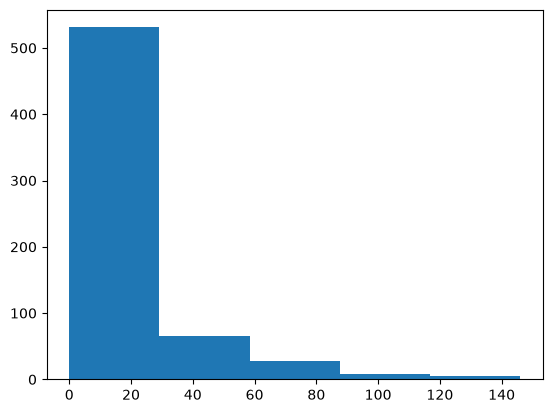

In [64]:
import matplotlib.pyplot as plt
plt.hist(match['win_by_runs'],bins=5) 

C:\Users\suhav\AppData\Local\Temp\ipykernel_15452\374280056.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(match['win_by_runs'])


<Axes: xlabel='win_by_runs', ylabel='Density'>

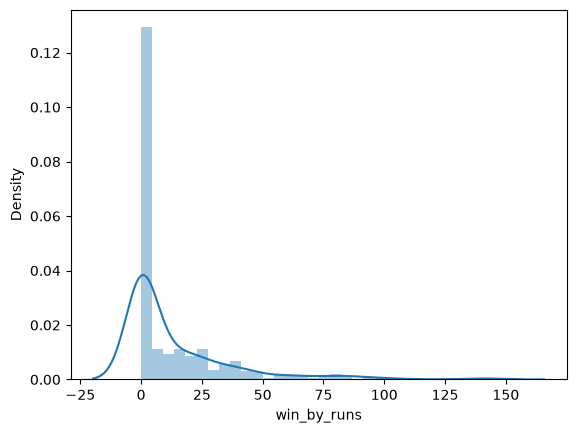

In [65]:
sns.distplot(match['win_by_runs'])

<Axes: ylabel='win_by_runs'>

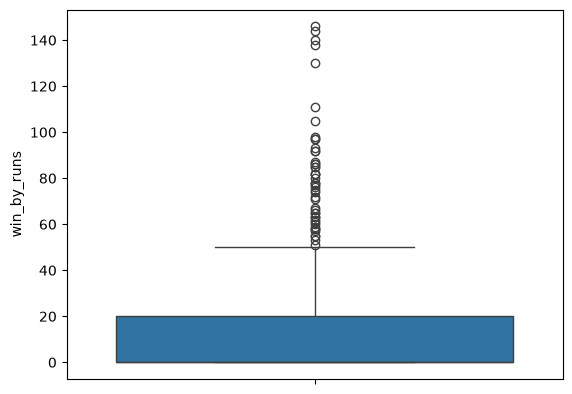

In [66]:
sns.boxplot(match['win_by_runs'])